In [6]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:, 0]      # Lead MLII
fs = record.fs                      # 360 Hz
r_peaks = annotation.sample
labels = annotation.symbol

In [3]:
import matplotlib.pyplot as plt

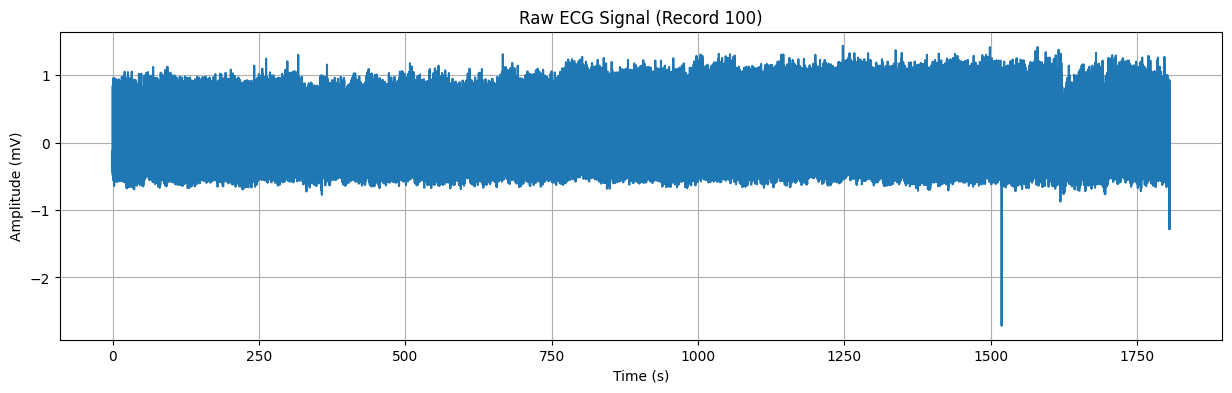

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis
t = np.arange(len(signal)) / fs

plt.figure(figsize=(15,4))
plt.plot(t, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Raw ECG Signal (Record 100)")
plt.grid(True)
plt.show()

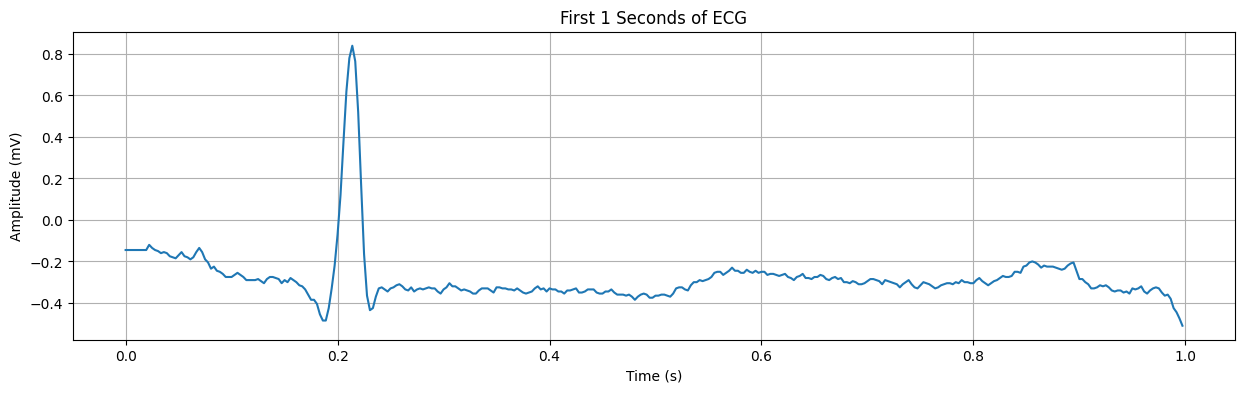

In [8]:
start = 0
duration = 1   # seconds

samples = duration * fs
t = np.arange(len(signal)) / fs
plt.figure(figsize=(15,4))
plt.plot(t[start:samples], signal[start:samples])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("First 1 Seconds of ECG")
plt.grid(True)
plt.show()

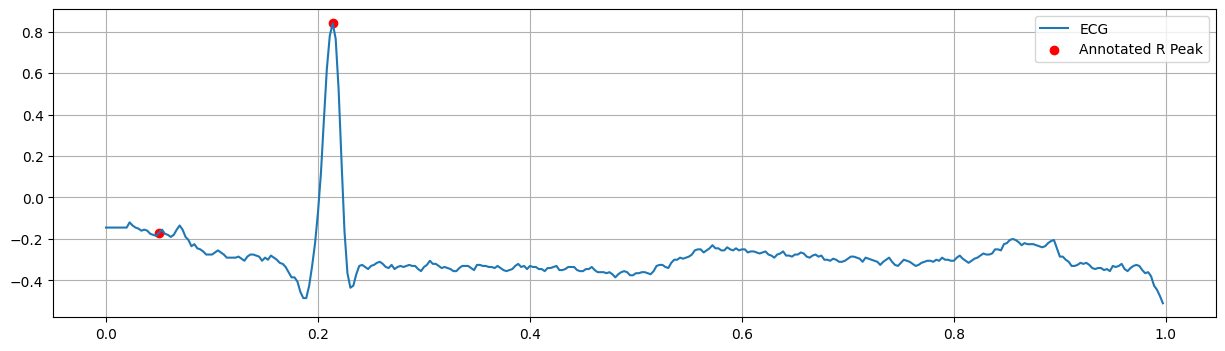

In [10]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], signal[:samples], label="ECG")

# R peaks in first 10 seconds
mask = r_peaks < samples


plt.scatter(
    r_peaks[mask] / fs,
    signal[r_peaks[mask]],
    color='red',
    label='Annotated R Peak'
)

plt.legend()
plt.grid(True)
plt.show()

In [11]:
from scipy.signal import butter, filtfilt

def bandpass(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    filtered = filtfilt(b, a, signal)

    return filtered

filtered = bandpass(signal)

C:\Users\aadit\AppData\Local\Temp\ipykernel_30340\791887304.py:7: RuntimeWarning: divide by zero encountered in divide
  f = 1/t


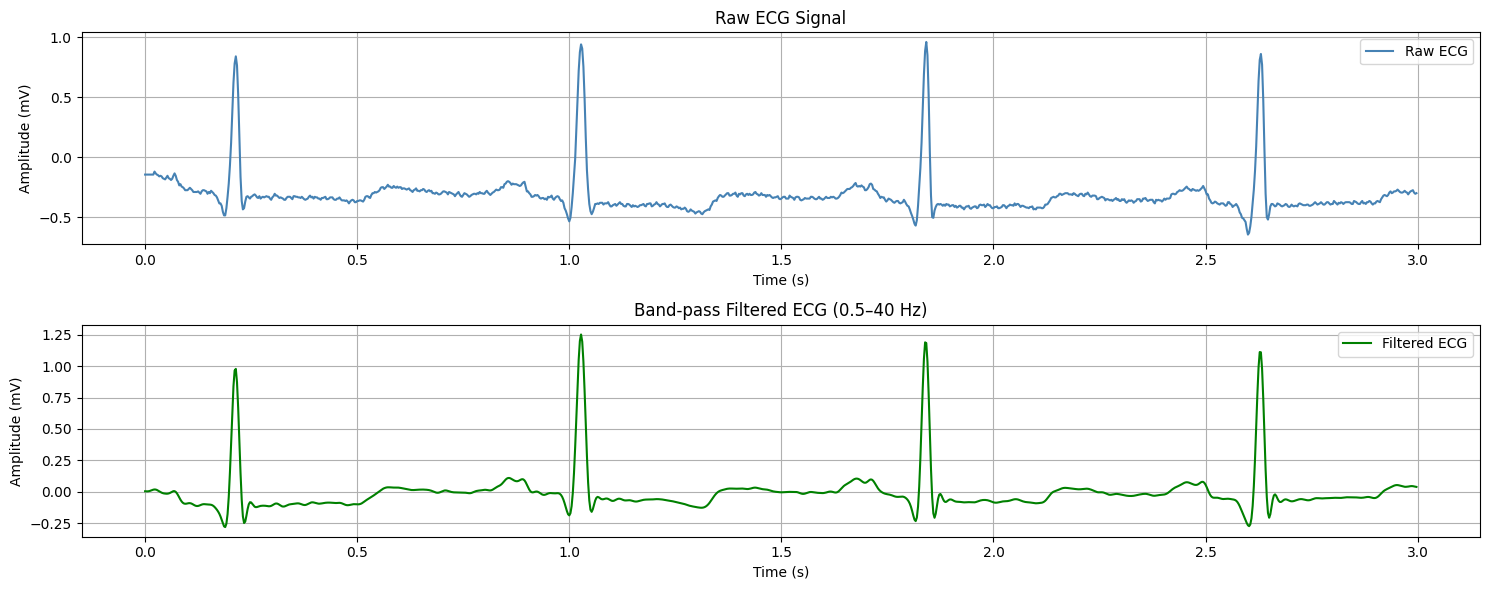

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis
t = np.arange(len(signal)) / fs

f = 1/t

duration = 3
samples = duration * fs

plt.figure(figsize=(15,6))

# ---------------- Raw ECG ----------------
plt.subplot(2,1,1)
plt.plot(t[:samples], signal[:samples], color='steelblue', label='Raw ECG')
plt.title("Raw ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()


plt.legend()

# ---------------- Filtered ECG ----------------
plt.subplot(2,1,2)
plt.plot(t[:samples], filtered[:samples], color='green', label='Filtered ECG')
plt.title("Band-pass Filtered ECG (0.5–40 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

kernel = np.array([-1, -2, 0, 2, 1]) / 8.0

derivative = np.convolve(filtered, kernel, mode='same')

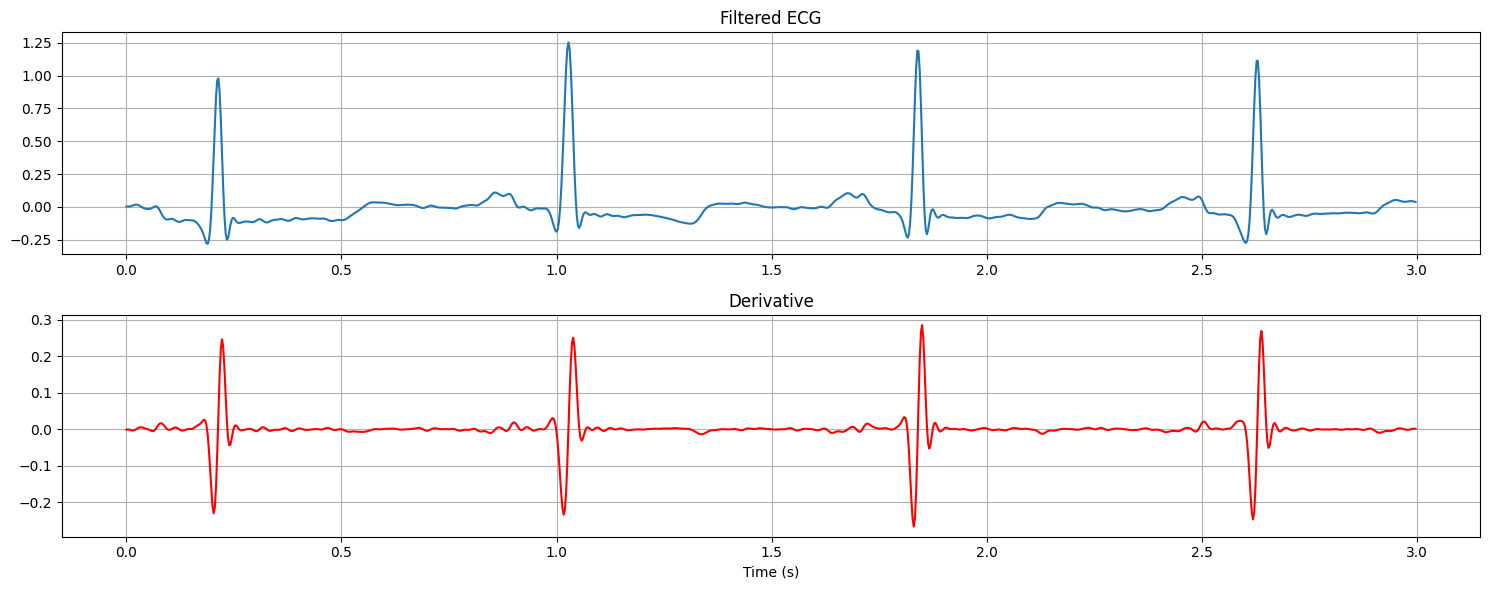

In [32]:
import matplotlib.pyplot as plt

duration = 3
samples = duration * fs
t = np.arange(len(filtered)) / fs

plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t[:samples], filtered[:samples])

plt.title("Filtered ECG")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t[:samples], derivative[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
squared = derivative**2 

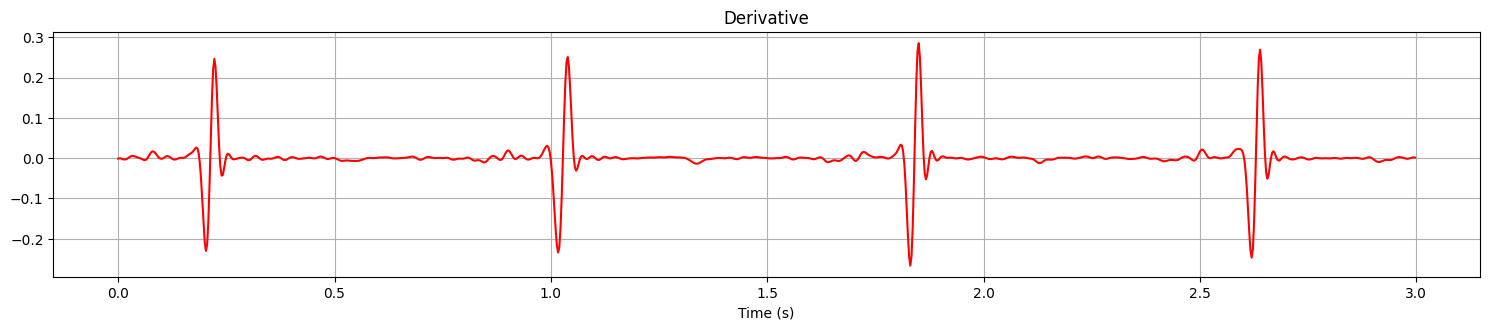

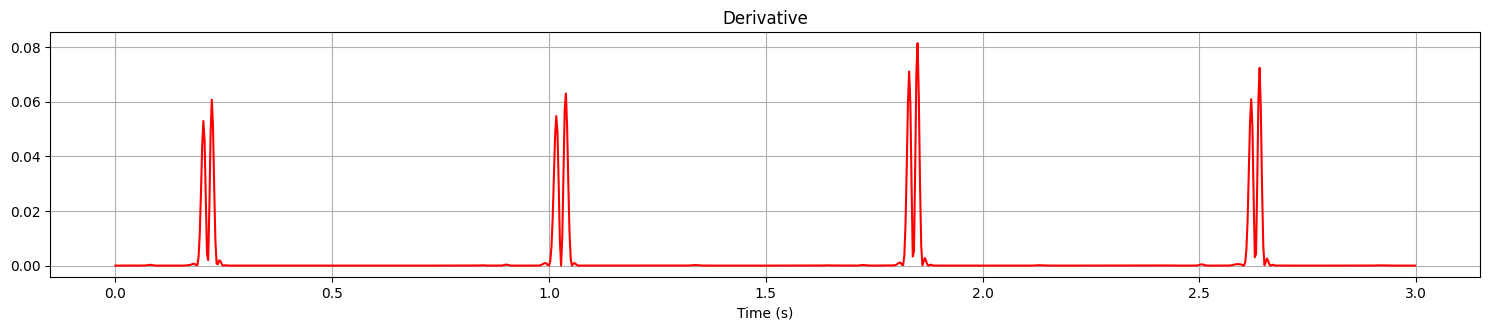

In [34]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t[:samples], derivative[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], squared[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
N = 54
mwi = np.zeros(len(squared))

for n in range(N - 1, len(squared)):
    window_sum = 0

    for i in range(N):
        window_sum += squared[n - i]

    mwi[n] = window_sum / N

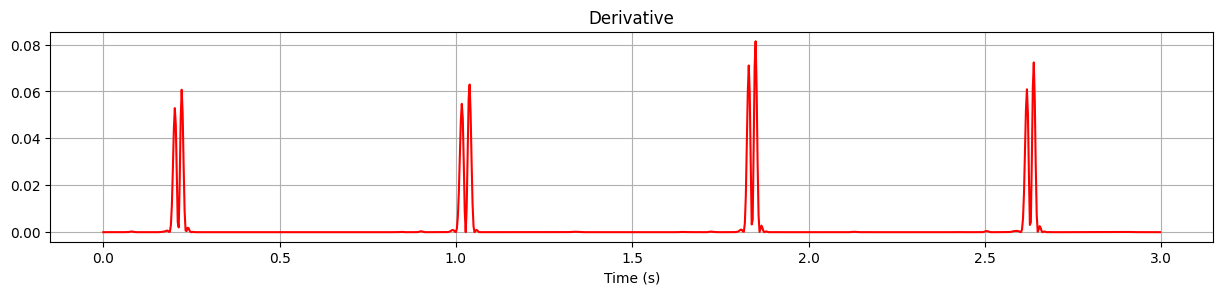

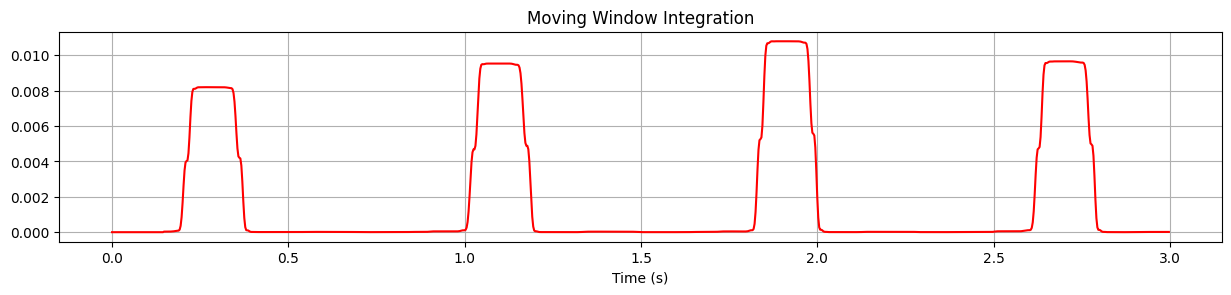

In [37]:

plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], squared[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)


plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], mwi[:samples], color='red')
plt.title("Moving Window Integration")
plt.xlabel("Time (s)")
plt.grid(True)

In [49]:
threshold = 0.4 * np.max(mwi)

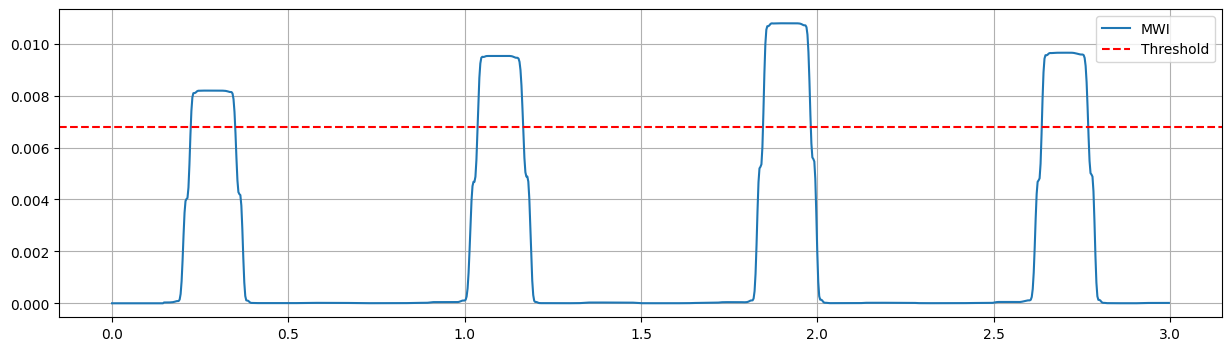

In [50]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples], label="MWI")
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')

plt.legend()
plt.grid(True)
plt.show()

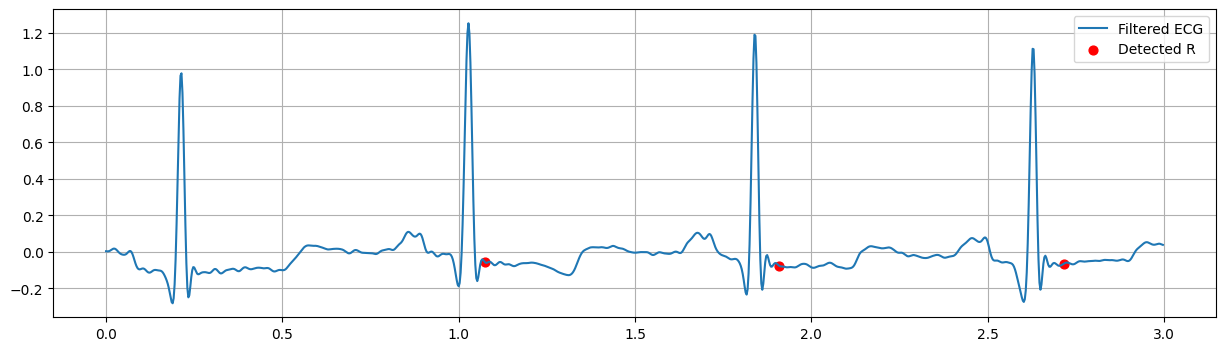

In [51]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], filtered[:samples], label="Filtered ECG")

mask = peaks < samples

plt.scatter(
    peaks[mask]/fs,
    filtered[peaks[mask]],
    color='red',
    s=40,
    label='Detected R'
)

plt.legend()
plt.grid(True)
plt.show()

In [45]:
search = int(0.15 * fs / 2)      # Half the integration window (~27 samples)

r_detected = []

for p in peaks:

    start = max(0, p - search)
    end = min(len(filtered), p + search)

    # Highest point in filtered ECG
    r = start + np.argmax(filtered[start:end])

    r_detected.append(r)

r_detected = np.array(r_detected)

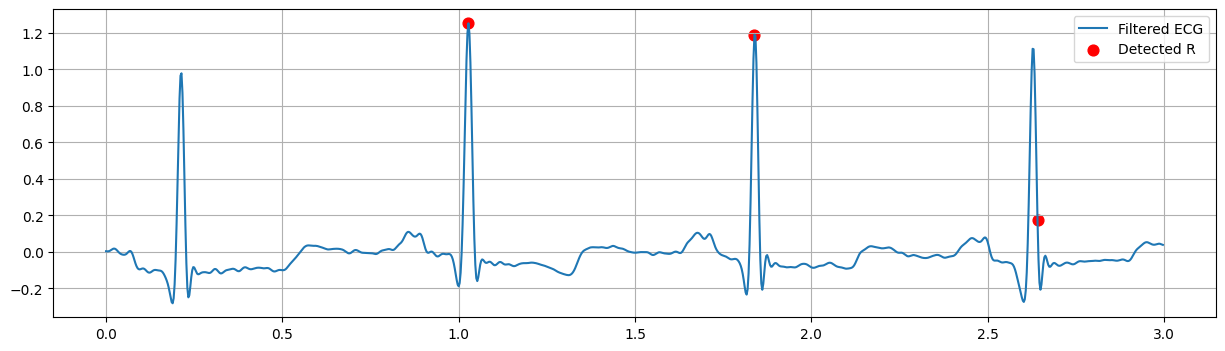

In [46]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], filtered[:samples], label="Filtered ECG")

mask = r_detected < samples

plt.scatter(
    r_detected[mask]/fs,
    filtered[r_detected[mask]],
    color='red',
    s=60,
    label='Detected R'
)

plt.legend()
plt.grid(True)
plt.show()

In [47]:
search = int(0.15 * fs)

for p in peaks:

    start = max(0, p - search)
    end = p

    r = start + np.argmax(filtered[start:end])

In [48]:
print("MWI Peaks:", peaks)
print("Detected R:", r_detected)
print("Annotated:", r_peaks[r_peaks < samples])

MWI Peaks: [   387    687    978 ... 649243 649519 649749]
Detected R: [   370    662    951 ... 649232 649497 649733]
Annotated: [ 18  77 370 662 946]
